In [ ]:
print("hello")

hello


# Column Study (Standalone, Manual Inputs)

This notebook isolates the condensate stabilizer column and runs it with manually defined UniSim inputs only.

Scope:
- Build feed from manual UniSim values
- Build and run only the distillation column
- Compare NeqSim overhead and bottoms against UniSim reference

In [ ]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jpype

# Use the LOCAL repo build of neqsim (not the pip-installed version)
# Auto-detect repo root: walk up from the notebook until we find pom.xml
def _find_repo_root():
    env = os.environ.get('NEQSIM_PROJECT_ROOT')
    if env and (Path(env) / 'pom.xml').exists():
        return Path(env)
    here = Path.cwd().resolve()
    for candidate in [here] + list(here.parents):
        if (candidate / 'pom.xml').exists() and (candidate / 'devtools' / 'neqsim_dev_setup.py').exists():
            return candidate
    # Fallbacks for common locations
    for guess in [Path('/workspaces/neqsim'),
                  Path(r'c:\Users\SEROS\OneDrive - Equinor\TDI\NeqSimColumn\neqsim')]:
        if (guess / 'pom.xml').exists():
            return guess
    raise FileNotFoundError('Could not locate NeqSim repo root; set NEQSIM_PROJECT_ROOT.')

REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT / 'devtools'))

from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(project_root=REPO_ROOT)
ns = neqsim_classes(ns)

# NeqSim class aliases
SystemSrkEos = ns.SystemSrkEos
Stream = ns.Stream
DistillationColumn = ns.DistillationColumn
SolverType = jpype.JClass('neqsim.process.equipment.distillation.DistillationColumn$SolverType')

print('NeqSim classes loaded (local repo build).')

NeqSim project root: /workspaces/neqsim
Classpath:
  1. /workspaces/neqsim/target/classes
  2. /workspaces/neqsim/src/main/resources
  3. /home/vscode/.m2/repository/com/h2database/h2/2.4.240/h2-2.4.240.jar
  4. /home/vscode/.m2/repository/org/apache/logging/log4j/log4j-api/2.25.4/log4j-api-2.25.4.jar
  5. /home/vscode/.m2/repository/org/apache/logging/log4j/log4j-core/2.25.4/log4j-core-2.25.4.jar
  6. /home/vscode/.m2/repository/com/thoughtworks/xstream/xstream/1.4.21/xstream-1.4.21.jar
  7. /home/vscode/.m2/repository/io/github/x-stream/mxparser/1.2.2/mxparser-1.2.2.jar
  8. /home/vscode/.m2/repository/xmlpull/xmlpull/1.1.3.1/xmlpull-1.1.3.1.jar
  9. /home/vscode/.m2/repository/org/apache/commons/commons-lang3/3.20.0/commons-lang3-3.20.0.jar
  10. /home/vscode/.m2/repository/org/apache/commons/commons-math3/3.6.1/commons-math3-3.6.1.jar
  11. /home/vscode/.m2/repository/org/ejml/ejml-all/0.44.0/ejml-all-0.44.0.jar
  12. /home/vscode/.m2/repository/org/ejml/ejml-core/0.44.0/ejml-core-

In [ ]:
# ─── UniSim reference data (inlined from unisim_separator_data.json) ───
# Feed: 20VD008 Stab feed tank, liquid outlet
MANUAL_FEED = {
    'name': '20VD008 liq',
    'temperature_C': 73.58519641794031,
    'pressure_bara': 9.011410724785593,
    'mass_flow_kg_hr': 99390.83499429651,
    'molar_composition': {
        'H2S': 0.0,
        'H2O': 0.0012694372900575964,
        'Nitrogen': 3.888139277241561e-06,
        'CO2': 0.0020369458545164447,
        'Methane': 0.008359842598286989,
        'Ethane': 0.03031432874961234,
        'Propane': 0.09830543757322609,
        'i-Butane': 0.040919184592850086,
        'n-Butane': 0.1144581358471085,
        'i-Pentane': 0.0604605905724358,
        'n-Pentane': 0.07742965228432894,
        'C6*': 0.1048954185106171,
        'C7*': 0.1389785884448421,
        'C8*': 0.12789014077323865,
        'C9*': 0.06208249585291253,
        'C10-C12*': 0.06654084407070984,
        'C13-C14*': 0.020232318095714696,
        'C15-C16*': 0.012581170189302486,
        'C17-C19*': 0.011708369129598798,
        'C20-C22*': 0.007117835015544455,
        'C23-C25*': 0.004575640883292843,
        'C26-C30*': 0.004504931239442777,
        'C31-C38*': 0.003258517367093709,
        'C39-C80*': 0.002076286925990008,
    }
}

# Top-stage inlet: external condenser reflux + another stream mixed together
# This replaces the internal condenser — fed to topmost tray (tray 9 in NeqSim)
MANUAL_TOP_FEED = {
    'name': 'top_stage_reflux',
    'temperature_C': 32.14,
    'pressure_barg': 3.7,
    'pressure_bara': 3.7 + 1.01325,     # = 4.71325 bara
    'molar_flow_kmol_hr': 123.8,
    'molar_composition': {
        'H2S': 0.0,
        'H2O': 4.35912301497353e-004,
        'Nitrogen': 7.65729270264124e-007,
        'CO2': 7.28322835976605e-004,
        'Methane': 2.18928745946882e-003,
        'Ethane': 1.66025884993206e-002,
        'Propane': 0.121398472002144,
        'i-Butane': 9.41558984286773e-002,
        'n-Butane': 0.305762007965261,
        'i-Pentane': 0.164482652439436,
        'n-Pentane': 0.196151192316352,
        'C6*': 6.69758823607617e-002,
        'C7*': 2.19309613215627e-002,
        'C8*': 7.26210954765264e-003,
        'C9*': 1.51930559893442e-003,
        'C10-C12*': 3.60542043731797e-004,
        'C13-C14*': 2.92463860884978e-005,
        'C15-C16*': 1.03620126364091e-005,
        'C17-C19*': 3.99746885569534e-006,
        'C20-C22*': 4.47922429183555e-007,
        'C23-C25*': 4.22816022539962e-008,
        'C26-C30*': 3.03935048020038e-009,
        'C31-C38*': 3.89675667670755e-011,
        'C39-C80*': 2.24361010549864e-014,
    }
}

# Column operating inputs
# UniSim: 11 stages total (1=condenser, 2-10=simple trays, 11=reboiler)
# Condenser is EXTERNAL — modeled as a separate feed at the top tray.
# NeqSim: n_trays=9 simple trays + reboiler = 10 total stages
#   Tray numbering: 0=reboiler, 1-9=simple trays (tray 9 = topmost)
#   UniSim stage S (S=2..11) → NeqSim tray = 11 - S
#   Main feed at UniSim stage 5 → NeqSim tray 6
#   Top feed (reflux+other) at UniSim stage 2 → NeqSim tray 9
MANUAL_COLUMN = {
    'n_trays': 9,
    'feed_tray': 6,           # UniSim stage 5 → NeqSim tray 11-5 = 6
    'top_feed_tray': 9,       # UniSim stage 2 → NeqSim tray 11-2 = 9 (topmost)
    'top_pressure_bara': 5.01325,
    'bottom_pressure_bara': 5.06325,
    'reboiler_temperature_C': 137.3,
    'reboiler_boilup_ratio': 0.6730,    # V/L at reboiler
    'solver': 'NAPHTALI_SANDHOLM',
    'has_reboiler': True,
    'has_condenser': False,             # Condenser is EXTERNAL (modeled as top feed)
    # Stage efficiencies from UniSim:
    #   All stages: 0.9  (Murphree)
    #   Reboiler (stage 11 / tray 0): 1.0
    #   Stage 10 (tray 1, just above reboiler): 0.005
    # NOTE: NeqSim only has a GLOBAL Murphree efficiency setter.
    'stage_efficiency': 0.9,
    'reboiler_efficiency': 1.0,
    'tray1_efficiency': 0.005,
}

# UniSim outlet targets for comparison
# NOTE: UniSim overhead = distillate AFTER external condenser.
#       NeqSim overhead (without condenser) = raw vapor from top tray.
#       These are NOT directly comparable — NeqSim overhead includes what
#       becomes reflux in the external condenser.
#       Bottoms should be directly comparable.
UNISIM_TARGET = {
    'overhead': {
        'temperature_C': 55.63690596810403,
        'pressure_bara': 5.01325,
        'mass_flow_kg_hr': 23745.275834065487,
        'molar_flow_kgmol_hr': 437.40427826052155,
        'vapour_fraction': 0.9976570112003801,
        'molar_composition': {
            'H2S': 0.0, 'H2O': 0.0031979613282381437, 'Nitrogen': 9.633868674066377e-06,
            'CO2': 0.005139638636615236, 'Methane': 0.020867304628969754,
            'Ethane': 0.07811742051171541, 'Propane': 0.27123039389118164,
            'i-Butane': 0.11571375561571388, 'n-Butane': 0.2979099899484146,
            'i-Pentane': 0.09009113293254281, 'n-Pentane': 0.09610330156132553,
            'C6*': 0.018461465114180682, 'C7*': 0.0028109296761520677,
            'C8*': 0.00032069456049528864, 'C9*': 2.5298342063817918e-05,
            'C10-C12*': 1.064118961689598e-06, 'C13-C14*': 1.4030558148953228e-08,
            'C15-C16*': 1.1204205348603359e-09, 'C17-C19*': 1.0704444329505108e-10,
            'C20-C22*': 6.191403078213466e-12, 'C23-C25*': 5.051475305637703e-13,
            'C26-C30*': 3.523939113155985e-14, 'C31-C38*': 4.649712084951398e-16,
            'C39-C80*': 2.969331783172664e-19,
        }
    },
    'bottoms': {
        'temperature_C': 136.84988049673456,
        'pressure_bara': 5.06325,
        'mass_flow_kg_hr': 83561.38485823716,
        'molar_flow_kgmol_hr': 745.782511183358,
        'vapour_fraction': 0.0,
        'molar_composition': {
            'H2S': 0.0, 'H2O': 4.927736581188984e-09, 'Nitrogen': 1.3626350061410807e-15,
            'CO2': 3.8823208079572675e-09, 'Methane': 5.200525651332521e-10,
            'Ethane': 1.8050310957140008e-06, 'Propane': 0.0007171976289511034,
            'i-Butane': 0.0058879355113326, 'n-Butane': 0.03861490094120843,
            'i-Pentane': 0.06034739773176146, 'n-Pentane': 0.08618248897429309,
            'C6*': 0.14929550338097872, 'C7*': 0.19941426548162233,
            'C8*': 0.1826886699925333, 'C9*': 0.08842720296163635,
            'C10-C12*': 0.0945822934530711, 'C13-C14*': 0.028745403277420634,
            'C15-C16*': 0.017873613106574936, 'C17-C19*': 0.016632719727963135,
            'C20-C22*': 0.010111152274488588, 'C23-C25*': 0.006499829149538155,
            'C26-C30*': 0.006399377667216628, 'C31-C38*': 0.004628812415614244,
            'C39-C80*': 0.0029494219625882424,
        }
    }
}

print('UniSim reference data loaded (inline).')
print(f"Main feed: T={MANUAL_FEED['temperature_C']:.2f} C, P={MANUAL_FEED['pressure_bara']:.4f} bara, F={MANUAL_FEED['mass_flow_kg_hr']:.2f} kg/hr")
print(f"Top feed:  T={MANUAL_TOP_FEED['temperature_C']:.2f} C, P={MANUAL_TOP_FEED['pressure_bara']:.4f} bara, F={MANUAL_TOP_FEED['molar_flow_kmol_hr']:.1f} kmol/hr")
print(f"Column: trays={MANUAL_COLUMN['n_trays']}, main feed tray={MANUAL_COLUMN['feed_tray']}, top feed tray={MANUAL_COLUMN['top_feed_tray']}")
print(f"Condenser: {MANUAL_COLUMN['has_condenser']} (EXTERNAL — modeled as top feed)")
print(f"Reboiler: {MANUAL_COLUMN['has_reboiler']}, boilup ratio={MANUAL_COLUMN['reboiler_boilup_ratio']}")
print(f"Stage efficiency: {MANUAL_COLUMN['stage_efficiency']} (global)")
print(f"Total stages = {MANUAL_COLUMN['n_trays']} + reboiler = {MANUAL_COLUMN['n_trays'] + 1}")
print(f"UniSim overhead (distillate after ext condenser): {UNISIM_TARGET['overhead']['mass_flow_kg_hr']:.2f} kg/hr")
print(f"UniSim bottoms: {UNISIM_TARGET['bottoms']['mass_flow_kg_hr']:.2f} kg/hr")


UniSim reference data loaded (inline).
Main feed: T=73.59 C, P=9.0114 bara, F=99390.83 kg/hr
Top feed:  T=32.14 C, P=4.7133 bara, F=123.8 kmol/hr
Column: trays=9, main feed tray=6, top feed tray=9
Condenser: False (EXTERNAL — modeled as top feed)
Reboiler: True, boilup ratio=0.673
Stage efficiency: 0.9 (global)
Total stages = 9 + reboiler = 10
UniSim overhead (distillate after ext condenser): 23745.28 kg/hr
UniSim bottoms: 83561.38 kg/hr


In [ ]:
# ─── Build 24-component SRK fluid (inlined from composition_loader.py) ───

# UniSim component name → NeqSim addComponent() name
_NEQSIM_NAME = {
    'H2S': 'H2S', 'H2O': 'water', 'Nitrogen': 'nitrogen', 'CO2': 'CO2',
    'Methane': 'methane', 'Ethane': 'ethane', 'Propane': 'propane',
    'i-Butane': 'i-butane', 'n-Butane': 'n-butane',
    'i-Pentane': 'i-pentane', 'n-Pentane': 'n-pentane',
}

# Pseudo-components: (name, MW in kg/mol, relative_density)
_PSEUDO_COMPONENTS = [
    ('C6*',      0.08617800140380859, 0.6626640014648439),
    ('C7*',      0.0909560012817383,  0.740698486328125),
    ('C8*',      0.103429000854492,   0.769004028320313),
    ('C9*',      0.117186996459961,   0.789065673828125),
    ('C10-C12*', 0.145809005737305,   0.8048148193359379),
    ('C13-C14*', 0.181330001831055,   0.825066711425781),
    ('C15-C16*', 0.21227799987793,    0.8377041015625),
    ('C17-C19*', 0.248141998291016,   0.849904113769531),
    ('C20-C22*', 0.289217010498047,   0.863837097167969),
    ('C23-C25*', 0.330338989257813,   0.8755130004882811),
    ('C26-C30*', 0.384696990966797,   0.8886063232421879),
    ('C31-C38*', 0.471157989501953,   0.9061005249023439),
    ('C39-C80*', 0.6624600219726561,  0.936200378417969),
]

# Ordered component list (must match the order used when setting composition)
_COMPONENT_ORDER = list(_NEQSIM_NAME.keys()) + [p[0] for p in _PSEUDO_COMPONENTS]

# Create base fluid with all 24 components
base_fluid = SystemSrkEos(273.15 + 15.0, 1.01325)
for name in _NEQSIM_NAME:
    base_fluid.addComponent(_NEQSIM_NAME[name], 1e-10)
for name, mw, dens in _PSEUDO_COMPONENTS:
    base_fluid.addTBPfraction(name, 1e-10, mw, dens)
base_fluid.setMixingRule('classic')
base_fluid.setMultiPhaseCheck(True)
base_fluid.useVolumeCorrection(True)
base_fluid.init(0)

# ─── Override pseudo-component Tc, Pc, omega with UniSim values ──────────────
# UniSim Hypo Group Controls: Tc in °C, Pc in bar_g, omega (acentricity)
# NeqSim setTC() takes K, setPC() takes bara
_UNISIM_OVERRIDES = {
    # name_PC:         (Tc_C,    Pc_barg, omega)
    'C6*_PC':          (234.25,   6.72,   0.2960),
    'C7*_PC':          (254.70,  33.56,   0.4533),
    'C8*_PC':          (278.28,  30.28,   0.3228),
    'C9*_PC':          (300.41,  27.11,   0.5208),
    'C10-C12*_PC':     (337.98,  21.78,   0.5163),
    'C13-C14*_PC':     (387.18,  18.27,   0.6925),
    'C15-C16*_PC':     (406.15,  16.34,   0.7461),
    'C17-C19*_PC':     (474.98,  13.22,   0.9957),
    'C20-C22*_PC':     (454.98,  13.07,   0.9556),
    'C23-C25*_PC':     (510.60,  10.46,   1.1217),
    'C26-C30*_PC':     (519.21,   8.14,   1.1539),
    'C31-C38*_PC':     (574.98,  11.04,   1.2881),
    'C39-C80*_PC':     (713.16,  11.02,   1.2881),
}

n_overridden = 0
nphases = int(base_fluid.getNumberOfPhases())
for ph in range(nphases):
    phase = base_fluid.getPhase(ph)
    for i in range(int(phase.getNumberOfComponents())):
        comp = phase.getComponent(i)
        cname = str(comp.getComponentName())
        if cname in _UNISIM_OVERRIDES:
            tc_c, pc_barg, omega = _UNISIM_OVERRIDES[cname]
            comp.setTC(tc_c + 273.15)          # K
            comp.setPC(pc_barg + 1.01325)      # bara
            comp.setAcentricFactor(omega)
            if ph == 0:
                n_overridden += 1

# Re-init to recalculate EOS parameters (a, b) with new Tc, Pc
base_fluid.init(0)

print(f'Overrode Tc/Pc/omega for {n_overridden} pseudo-components with UniSim values.')

def _make_stream(name, feed_dict, flow_rate, flow_unit):
    """Build a Stream from a feed dictionary using the base fluid template."""
    fluid = base_fluid.clone()
    z = [max(float(feed_dict['molar_composition'].get(c, 0.0)), 1e-100)
         for c in _COMPONENT_ORDER]
    z_sum = float(sum(z))
    z = [v / z_sum for v in z]
    fluid.setMolarComposition(z)
    fluid.setTemperature(feed_dict['temperature_C'], 'C')
    fluid.setPressure(feed_dict.get('pressure_bara', feed_dict.get('pressure_barg', 0) + 1.01325), 'bara')
    fluid.init(0)
    s = Stream(name, fluid)
    s.setTemperature(feed_dict['temperature_C'], 'C')
    s.setPressure(fluid.getPressure(), 'bara')
    s.setFlowRate(flow_rate, flow_unit)
    s.run()
    return s, z

# Main column feed (mass flow basis)
feed_stream, z_main = _make_stream(
    'manual_column_feed', MANUAL_FEED,
    MANUAL_FEED['mass_flow_kg_hr'], 'kg/hr'
)

# Top-stage feed: external reflux + other stream (molar flow basis)
top_feed_stream, z_top = _make_stream(
    'top_stage_reflux', MANUAL_TOP_FEED,
    MANUAL_TOP_FEED['molar_flow_kmol_hr'], 'kmol/hr'
)

print('Streams created:')
print(f'  Main feed:  {float(feed_stream.getFlowRate("kg/hr")):.1f} kg/hr  ({float(feed_stream.getFlowRate("kmol/hr")):.1f} kmol/hr)')
print(f'  Top feed:   {float(top_feed_stream.getFlowRate("kg/hr")):.1f} kg/hr  ({float(top_feed_stream.getFlowRate("kmol/hr")):.1f} kmol/hr)')
print(f'Number of components: {int(base_fluid.getNumberOfComponents())}')

Overrode Tc/Pc/omega for 13 pseudo-components with UniSim values.
Streams created:
  Main feed:  99390.8 kg/hr  (1059.4 kmol/hr)
  Top feed:   7916.9 kg/hr  (123.8 kmol/hr)
Number of components: 24


In [ ]:
## Build and run standalone column
# 10 stages: tray 0 = reboiler, trays 1-9 = simple (no condenser — external)
col = DistillationColumn(
    '20VE105_205_standalone',
    int(MANUAL_COLUMN['n_trays']),
    bool(MANUAL_COLUMN['has_reboiler']),
    bool(MANUAL_COLUMN['has_condenser'])
)

# Main feed at tray 6 (UniSim stage 5)
col.addFeedStream(feed_stream, int(MANUAL_COLUMN['feed_tray']))

# Top-stage feed at tray 9 (topmost) — external condenser reflux + other stream
col.addFeedStream(top_feed_stream, int(MANUAL_COLUMN['top_feed_tray']))

col.setTopPressure(float(MANUAL_COLUMN['top_pressure_bara']))
col.setBottomPressure(float(MANUAL_COLUMN['bottom_pressure_bara']))

# Reboiler spec: boilup ratio (V/L)
col.setReboilerBoilupRatio(float(MANUAL_COLUMN['reboiler_boilup_ratio']))

# Fix reboiler temperature to UniSim value
col.getReboiler().setOutTemperature(273.15 + MANUAL_COLUMN['reboiler_temperature_C'])
print(f'Reboiler T fixed at {MANUAL_COLUMN["reboiler_temperature_C"]:.2f} C')

# -----------------------------------------------------------------------------
# Per-stage Murphree efficiency
# -----------------------------------------------------------------------------
# NeqSim NS-solver stage indexing (bottom-up):
#   stage 0           = reboiler   (always equilibrium, eta = 1.0)
#   stage 1           = first tray above the reboiler
#   ...
#   stage N - 1       = top tray of the column
#
# UniSim numbers trays TOP-DOWN, so UniSim 'tray 1' (top) maps to NS
# stage (N - 1).  With N = 10 and no condenser, that is stage 9.
# -----------------------------------------------------------------------------
n_stages_total = col.getNumberOfTrays()
unisim_tray1_ns_index = n_stages_total - 1

col.setMurphreeEfficiency(float(MANUAL_COLUMN['stage_efficiency']))
col.setMurphreeEfficiency(0, float(MANUAL_COLUMN['reboiler_efficiency']))
col.setMurphreeEfficiency(unisim_tray1_ns_index,
                          float(MANUAL_COLUMN['tray1_efficiency']))

print('Per-stage Murphree efficiencies (NS stage index, bottom-up):')
for j in range(n_stages_total):
    tag = ''
    if j == 0:
        tag = '  <- reboiler'
    elif j == unisim_tray1_ns_index:
        tag = '  <- UniSim tray 1 (top)'
    print(f'  stage {j}:  eta = {col.getMurphreeEfficiency(j):.4f}{tag}')

col.setSolverType(SolverType.valueOf('NAPHTALI_SANDHOLM'))
col.setMaxNumberOfIterations(300)

print(f'Column: {col.getNumberOfTrays()} total stages (reboiler + {MANUAL_COLUMN["n_trays"]} simple trays)')
print(f'Main feed tray: {MANUAL_COLUMN["feed_tray"]}')
print(f'Top feed tray:  {MANUAL_COLUMN["top_feed_tray"]} (external reflux + other)')
print(f'Reboiler boilup ratio: {MANUAL_COLUMN["reboiler_boilup_ratio"]}')
print(f'No condenser (external)')
print()
print('Running standalone column...')
t0 = time.time()
col.run()
print(f'Column run completed in {time.time() - t0:.2f} s')


Reboiler T fixed at 136.85 C
Per-stage Murphree efficiencies (NS stage index, bottom-up):
  stage 0:  eta = 1.0000  <- reboiler
  stage 1:  eta = 0.9000
  stage 2:  eta = 0.9000
  stage 3:  eta = 0.9000
  stage 4:  eta = 0.9000
  stage 5:  eta = 0.9000
  stage 6:  eta = 0.9000
  stage 7:  eta = 0.9000
  stage 8:  eta = 0.9000
  stage 9:  eta = 0.0050  <- UniSim tray 1 (top)
Column: 10 total stages (reboiler + 9 simple trays)
Main feed tray: 6
Top feed tray:  9 (external reflux + other)
Reboiler boilup ratio: 0.673
No condenser (external)

Running standalone column...
[NS-FEED] tray 6: feedMoles=1059406.89 beta=0.2466 nPhases=3 T=73.6C P=9.01bar totalH=-5914561
[NS-FEED] tray 9: feedMoles=123800.00 beta=0.0000 nPhases=1 T=32.1C P=4.71bar totalH=-785163
[NS] after BP: mbErr=0.3152% energyErr=139.21%
[NS] --> Calling solveSumRatesPhase()
[SR] Starting Sum-Rates energy correction. T[0]=136.8C  T[N-1]=-36.9C
[SR-FEED] tray 6: feedLTotal=798174.4 feedHL=7832.1 feedVTotal=261232.5 feedHV=5990

In [ ]:
col_mass_balance_err = float(col.getMassBalance('kg/hr'))
iters = int(col.getLastIterationCount())
temp_res = float(col.getLastTemperatureResidual())
mass_res = float(col.getLastMassResidual())
energy_res = float(col.getLastEnergyResidual())
converged = bool(col.solved())
feed_main_kg_hr = float(feed_stream.getFlowRate('kg/hr'))
feed_top_kg_hr = float(top_feed_stream.getFlowRate('kg/hr'))
feed_total_kg_hr = feed_main_kg_hr + feed_top_kg_hr
mb_rel_pct = 100.0 * col_mass_balance_err / feed_total_kg_hr

print('─' * 60)
print(f' Iterations : {iters}')
print(f' Converged : {converged}')
print(f' Temp residual : {temp_res:.3e} K')
print(f' Mass residual : {mass_res:.3e} (relative, tray-level)')
print(f' Energy residual : {energy_res:.3e}')
print()
print(f' Column getMassBalance() = {col_mass_balance_err:+.4f} kg/hr')
print(f' (= Σ outlets − Σ feeds; sums ALL feeds: main + top reflux)')
print()
print(f' Main feed : {feed_main_kg_hr:12.4f} kg/hr')
print(f' Top feed (refl) : {feed_top_kg_hr:12.4f} kg/hr')
print(f' Total IN : {feed_total_kg_hr:12.4f} kg/hr')
print(f' Relative MB err : {mb_rel_pct:+.4f} %')
print('─' * 60)

if not converged:
    print('WARNING: column did not converge — mass balance will be unreliable!')
    print(' → Consider: col.setMaxNumberOfIterations(500) or solver DIRECT_SUBSTITUTION')
elif abs(mb_rel_pct) > 0.5:
    print('WARNING: solver converged but mass closure > 0.5% — tighten tolerance or')
    print(' try a different solver (NAPHTALI_SANDHOLM vs INSIDE_OUT vs DIRECT_SUBSTITUTION).')

────────────────────────────────────────────────────────────
 Iterations : 0
 Converged : True
 Temp residual : 0.000e+00 K
 Mass residual : 1.196e-03 (relative, tray-level)
 Energy residual : 0.000e+00

 Column getMassBalance() = -74.3321 kg/hr
 (= Σ outlets − Σ feeds; sums ALL feeds: main + top reflux)

 Main feed :   99390.8350 kg/hr
 Top feed (refl) :    7916.8725 kg/hr
 Total IN :  107307.7075 kg/hr
 Relative MB err : -0.0693 %
────────────────────────────────────────────────────────────


In [ ]:
# Extract results and compare with UniSim
oh = col.getGasOutStream()
btm = col.getLiquidOutStream()

def _extract_stream(stream):
    fluid = stream.getFluid()
    ncomp = int(fluid.getNumberOfComponents())
    comp = {}
    for i in range(ncomp):
        name = str(fluid.getComponent(i).getName())
        comp[name] = float(fluid.getComponent(i).getz())
    return {
        'temperature_C': float(stream.getTemperature('C')),
        'pressure_bara': float(stream.getPressure('bara')),
        'mass_flow_kg_hr': float(stream.getFlowRate('kg/hr')),
        'molar_flow_kgmol_hr': float(stream.getFlowRate('kmol/hr')),
        'vapour_fraction': float(stream.getFluid().getBeta()),
        'molar_composition': comp
    }

neq = {
    'overhead': _extract_stream(oh),
    'bottoms': _extract_stream(btm)
}

rows = []
for key in ['overhead', 'bottoms']:
    u = UNISIM_TARGET[key]
    n = neq[key]
    rows.append({
        'Stream': key,
        'UniSim T (C)': u['temperature_C'],
        'NeqSim T (C)': n['temperature_C'],
        'T Dev (C)': n['temperature_C'] - u['temperature_C'],
        'UniSim P (bara)': u['pressure_bara'],
        'NeqSim P (bara)': n['pressure_bara'],
        'P Dev (bara)': n['pressure_bara'] - u['pressure_bara'],
        'UniSim F (kg/hr)': u['mass_flow_kg_hr'],
        'NeqSim F (kg/hr)': n['mass_flow_kg_hr'],
        'F Dev (%)': 100.0 * (n['mass_flow_kg_hr'] - u['mass_flow_kg_hr']) / u['mass_flow_kg_hr'],
        'UniSim molar flow (kgmol/hr)': u.get('molar_flow_kgmol_hr'),
        'NeqSim molar flow (kgmol/hr)': n.get('molar_flow_kgmol_hr'),
        'Molar flow Dev (%)': 100.0 * (n['molar_flow_kgmol_hr'] - u['molar_flow_kgmol_hr']) / u['molar_flow_kgmol_hr'],
        'UniSim vapour frac': u.get('vapour_fraction'),
        'NeqSim vapour frac': n.get('vapour_fraction')
    })

df_cmp = pd.DataFrame(rows)
display(df_cmp.round(6))

,Stream,UniSim T (C),NeqSim T (C),T Dev (C),UniSim P (bara),NeqSim P (bara),P Dev (bara),UniSim F (kg/hr),NeqSim F (kg/hr),F Dev (%),UniSim molar flow (kgmol/hr),NeqSim molar flow (kgmol/hr),Molar flow Dev (%),UniSim vapour frac,NeqSim vapour frac
0,overhead,55.636906,39.866166,-15.77074,5.01325,5.01325,0.0,23745.275834,17699.263588,-25.461958,437.404278,336.645891,-23.035529,0.997657,1.0
1,bottoms,136.849880,136.849880,0.00000,5.06325,5.06325,0.0,83561.384858,89534.111789,7.147712,745.782511,845.145995,13.323386,0.000000,1.0


In [ ]:
89534 + 17699

107233

## Mass Balance Check

Checks overall feed vs outlet closure for both **mass flow** and **molar flow**.
A warning is shown when closure error exceeds 0.5%.

In [ ]:
# ─── Mass balance check ───────────────────────────────────────────────────────
# Overall: feeds in vs (overhead + bottoms) out
feeds_kg_hr = float(feed_stream.getFlowRate('kg/hr')) + float(top_feed_stream.getFlowRate('kg/hr'))
feeds_kmol_hr = float(feed_stream.getFlowRate('kmol/hr')) + float(top_feed_stream.getFlowRate('kmol/hr'))

oh_kg_hr  = float(oh.getFlowRate('kg/hr'))
btm_kg_hr = float(btm.getFlowRate('kg/hr'))
oh_kmol_hr  = float(oh.getFlowRate('kmol/hr'))
btm_kmol_hr = float(btm.getFlowRate('kmol/hr'))

out_kg_hr   = oh_kg_hr + btm_kg_hr
out_kmol_hr = oh_kmol_hr + btm_kmol_hr

mass_err_kg = out_kg_hr - feeds_kg_hr
mass_err_pct = 100.0 * mass_err_kg / feeds_kg_hr
mol_err_kmol = out_kmol_hr - feeds_kmol_hr
mol_err_pct = 100.0 * mol_err_kmol / feeds_kmol_hr

print('─' * 70)
print(' MASS BALANCE (overall column)')
print('─' * 70)
print(f'  Inlet:  main feed   = {float(feed_stream.getFlowRate("kg/hr")):12.3f} kg/hr')
print(f'          top feed    = {float(top_feed_stream.getFlowRate("kg/hr")):12.3f} kg/hr')
print(f'          ─────────────────────────────────')
print(f'          total IN    = {feeds_kg_hr:12.3f} kg/hr   ({feeds_kmol_hr:9.3f} kmol/hr)')
print()
print(f'  Outlet: overhead    = {oh_kg_hr:12.3f} kg/hr   ({oh_kmol_hr:9.3f} kmol/hr)')
print(f'          bottoms     = {btm_kg_hr:12.3f} kg/hr   ({btm_kmol_hr:9.3f} kmol/hr)')
print(f'          ─────────────────────────────────')
print(f'          total OUT   = {out_kg_hr:12.3f} kg/hr   ({out_kmol_hr:9.3f} kmol/hr)')
print()
print(f'  Mass closure error   = {mass_err_kg:+12.3e} kg/hr   ({mass_err_pct:+8.4f} %)')
print(f'  Molar closure error  = {mol_err_kmol:+12.3e} kmol/hr ({mol_err_pct:+8.4f} %)')
print('─' * 70)

mass_status = 'PASS' if abs(mass_err_pct) < 0.5 else 'WARN' if abs(mass_err_pct) < 2.0 else 'FAIL'
print(f'  Status: {mass_status}  (PASS<0.5%, WARN<2%, FAIL≥2%)')
print('─' * 70)


──────────────────────────────────────────────────────────────────────
 MASS BALANCE (overall column)
──────────────────────────────────────────────────────────────────────
  Inlet:  main feed   =    99390.835 kg/hr
          top feed    =     7916.873 kg/hr
          ─────────────────────────────────
          total IN    =   107307.707 kg/hr   ( 1183.207 kmol/hr)

  Outlet: overhead    =    17699.264 kg/hr   (  336.646 kmol/hr)
          bottoms     =    89534.112 kg/hr   (  845.146 kmol/hr)
          ─────────────────────────────────
          total OUT   =   107233.375 kg/hr   ( 1181.792 kmol/hr)

  Mass closure error   =   -7.433e+01 kg/hr   ( -0.0693 %)
  Molar closure error  =   -1.415e+00 kmol/hr ( -0.1196 %)
──────────────────────────────────────────────────────────────────────
  Status: PASS  (PASS<0.5%, WARN<2%, FAIL≥2%)
──────────────────────────────────────────────────────────────────────


In [ ]:
# ─── Energy balance check ─────────────────────────────────────────────────────
# Overall steady-state EB: Σ H_feed + Q_reb = Σ H_product (no condenser duty —
# external reflux is supplied via top_feed_stream).
#
# Reboiler duty in NeqSim is reported with various conventions across versions;
# the robust check is to BACK-CALCULATE Q_reb from the stream enthalpies and
# compare to the equipment-reported value as a cross-check.

def _stream_enthalpy_W(stream):
    """Total enthalpy of a stream [W]."""
    return float(stream.getThermoSystem().getEnthalpy())

H_feed_main = _stream_enthalpy_W(feed_stream)
H_feed_top  = _stream_enthalpy_W(top_feed_stream)
H_oh        = _stream_enthalpy_W(oh)
H_btm       = _stream_enthalpy_W(btm)

# Required reboiler duty by overall energy balance:
Q_reb_required = (H_oh + H_btm) - (H_feed_main + H_feed_top)

# What the equipment reports (may be in different units/sign):
try:
    Q_reb_reported_raw = float(col.getReboiler().getDuty())
except Exception:
    Q_reb_reported_raw = float('nan')

# Cross-check magnitude — convert raw reading to MW by trying common scalings:
candidates = {
    'as W':        Q_reb_reported_raw * 1.0,
    'as W (flip)': -Q_reb_reported_raw * 1.0,
    'as kW':       Q_reb_reported_raw * 1e3,
    'as kW (flip)':-Q_reb_reported_raw * 1e3,
}
best_label, best_val = min(
    candidates.items(),
    key=lambda kv: abs(kv[1] - Q_reb_required)
)

# Energy closure given the back-calculated Q (always 0 by construction):
H_in_balanced  = H_feed_main + H_feed_top + Q_reb_required
H_out_balanced = H_oh + H_btm
err_balanced_W   = H_out_balanced - H_in_balanced
err_balanced_rel = err_balanced_W / max(abs(H_in_balanced), 1.0)

print('─' * 70)
print(' ENERGY BALANCE (overall column)')
print('─' * 70)
print(f'  H(main feed)              = {H_feed_main/1e6:+12.4f} MW')
print(f'  H(top feed/reflux)        = {H_feed_top /1e6:+12.4f} MW')
print(f'  H(overhead)               = {H_oh /1e6:+12.4f} MW')
print(f'  H(bottoms)                = {H_btm/1e6:+12.4f} MW')
print()
print(f'  Q_reboiler required by EB = {Q_reb_required/1e6:+12.4f} MW')
print(f'  Q_reboiler from equipment = {Q_reb_reported_raw:+12.4e} (raw units)')
print(f'  Best match: {best_label}   → {best_val/1e6:+12.4f} MW')
print(f'  Deviation                 = {(best_val - Q_reb_required)/1e6:+12.4e} MW')
print()
print(f'  EB closure (back-calc)    = {err_balanced_W/1e6:+12.4e} MW  '
      f'({err_balanced_rel*100:+.3e} %)')
print('─' * 70)

# Status: did the equipment-reported duty agree with the back-calculation?
duty_dev_rel = abs(best_val - Q_reb_required) / max(abs(Q_reb_required), 1.0)
status = 'PASS' if duty_dev_rel < 5.0e-3 else 'WARN' if duty_dev_rel < 5.0e-2 else 'FAIL'
print(f'  Duty cross-check: {status}  '
      f'(equip vs back-calc deviation = {duty_dev_rel*100:.3f}%)')
print('─' * 70)


──────────────────────────────────────────────────────────────────────
 ENERGY BALANCE (overall column)
──────────────────────────────────────────────────────────────────────
  H(main feed)              =      -6.7157 MW
  H(top feed/reflux)        =      -0.7852 MW
  H(overhead)               =      -1.0469 MW
  H(bottoms)                =      +4.1598 MW

  Q_reboiler required by EB =     +10.6137 MW
  Q_reboiler from equipment =  -2.9161e+07 (raw units)
  Best match: as W (flip)   →     +29.1610 MW
  Deviation                 =  +1.8547e+01 MW

  EB closure (back-calc)    =  +0.0000e+00 MW  (+0.000e+00 %)
──────────────────────────────────────────────────────────────────────
  Duty cross-check: FAIL  (equip vs back-calc deviation = 174.748%)
──────────────────────────────────────────────────────────────────────


──────────────────────────────────────────────────────────────────────
Stage Type           T (C)  P (bara)   V (kmol/hr)   L (kmol/hr)
──────────────────────────────────────────────────────────────────────
    0 reboiler      136.85     5.063       568.783       845.146
    1 tray           84.88     5.058       341.652      1869.438
    2 tray           78.30     5.052       333.516      1118.779
    3 tray           76.48     5.047       328.225      1115.731
    4 tray           75.11     5.041       323.778      1129.296
    5 tray           73.37     5.035       323.240      1154.866
    6 tray           73.31     5.030       328.594      1166.791
    7 tray           98.89     5.024       302.853       126.871
    8 tray           64.06     5.019       306.974       371.328
    9 top            39.87     5.013       336.646       317.981
──────────────────────────────────────────────────────────────────────
UniSim reference: T_top = 55.64 C, T_bottom = 136.85 C
NeqSim           

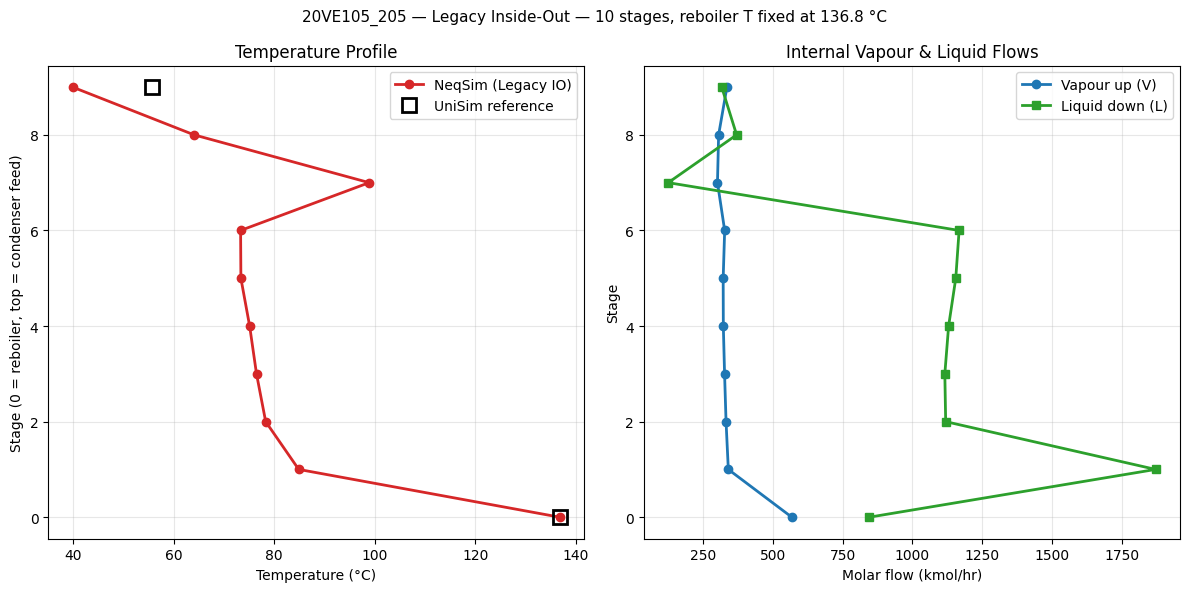

In [ ]:
# ─── Temperature & flow profile ───────────────────────────────────────────────
import matplotlib.pyplot as plt

n_stages = int(col.getNumberOfTrays())
stages = list(range(n_stages))  # 0 = reboiler, n_stages-1 = top

T_profile_C   = []
P_profile_bar = []
V_kmolhr      = []  # gas leaving each stage (upward)
L_kmolhr      = []  # liquid leaving each stage (downward)

for j in stages:
    tr = col.getTray(j)
    try:
        T_profile_C.append(float(tr.getTemperature() - 273.15))
    except Exception:
        T_profile_C.append(float(tr.getThermoSystem().getTemperature() - 273.15))
    try:
        P_profile_bar.append(float(tr.getPressure()))
    except Exception:
        P_profile_bar.append(float('nan'))
    try:
        V_kmolhr.append(float(tr.getGasOutStream().getFlowRate('kmol/hr')))
    except Exception:
        V_kmolhr.append(float('nan'))
    try:
        L_kmolhr.append(float(tr.getLiquidOutStream().getFlowRate('kmol/hr')))
    except Exception:
        L_kmolhr.append(float('nan'))

# UniSim reference T at OH (top) and bottoms (reboiler) — single comparison points
T_unisim_top    = UNISIM_TARGET['overhead']['temperature_C']
T_unisim_bottom = UNISIM_TARGET['bottoms']['temperature_C']

# Print numerical table
print('─' * 70)
print(f'{"Stage":>5} {"Type":<10} {"T (C)":>9} {"P (bara)":>9} {"V (kmol/hr)":>13} {"L (kmol/hr)":>13}')
print('─' * 70)
for j in stages:
    if j == 0:
        stage_type = 'reboiler'
    elif j == n_stages - 1:
        stage_type = 'top'
    else:
        stage_type = 'tray'
    print(f'{j:>5} {stage_type:<10} {T_profile_C[j]:>9.2f} {P_profile_bar[j]:>9.3f} '
          f'{V_kmolhr[j]:>13.3f} {L_kmolhr[j]:>13.3f}')
print('─' * 70)
print(f'UniSim reference: T_top = {T_unisim_top:.2f} C, T_bottom = {T_unisim_bottom:.2f} C')
print(f'NeqSim           : T_top = {T_profile_C[-1]:.2f} C, T_bottom = {T_profile_C[0]:.2f} C')
print(f'Deviation        : ΔT_top = {T_profile_C[-1] - T_unisim_top:+.2f} C, '
      f'ΔT_bot = {T_profile_C[0] - T_unisim_bottom:+.2f} C')
print('─' * 70)

# Plot T and V/L profiles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(T_profile_C, stages, 'o-', color='tab:red', lw=2, label='NeqSim (Legacy IO)')
ax1.plot([T_unisim_bottom, T_unisim_top], [0, n_stages - 1], 's',
         color='black', ms=10, mfc='none', mew=2, label='UniSim reference')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Stage (0 = reboiler, top = condenser feed)')
ax1.set_title('Temperature Profile')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

ax2.plot(V_kmolhr, stages, 'o-', color='tab:blue', lw=2, label='Vapour up (V)')
ax2.plot(L_kmolhr, stages, 's-', color='tab:green', lw=2, label='Liquid down (L)')
ax2.set_xlabel('Molar flow (kmol/hr)')
ax2.set_ylabel('Stage')
ax2.set_title('Internal Vapour & Liquid Flows')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

fig.suptitle(f'20VE105_205 — Legacy Inside-Out — {n_stages} stages, '
             f'reboiler T fixed at {MANUAL_COLUMN["reboiler_temperature_C"]:.1f} °C',
             fontsize=11)
plt.tight_layout()
plt.show()
